In [3]:
!pip install pandas mysql-connector-python numpy matplotlib seaborn statsmodels

In [7]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

In [1]:
!pip show mysql-connector-python

Name: mysql-connector-python
Version: 9.5.0
Summary: A self-contained Python driver for communicating with MySQL servers, using an API that is compliant with the Python Database API Specification v2.0 (PEP 249).
Home-page: 
Author: Oracle and/or its affiliates
Author-email: 
License: GNU GPLv2 (with FOSS License Exception)
Location: C:\Users\hp\anaconda3\Lib\site-packages
Requires: 
Required-by: 


In [3]:
import mysql.connector

conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Archita21!@",
    database="retail_analytics",
    port=3306,
    use_pure=True,          # IMPORTANT FIX
    connection_timeout=10
)

print("Connected Successfully")

Connected Successfully


In [5]:
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM fact_sales")
print(cursor.fetchone())

(51290,)


In [7]:
import pandas as pd

query = "SELECT * FROM fact_sales"
df = pd.read_sql(query, conn)

df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_9208\1573085570.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.14,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.04,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.64,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.06,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.77,4.70,Medium,2011


In [9]:
df.shape

(51290, 21)

In [11]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [13]:
df.dtypes

order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region             object
product_id         object
category           object
sub_category       object
product_name       object
sales             float64
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object
year                int64
dtype: object

In [15]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [17]:
df[['order_date', 'ship_date']].dtypes

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

In [19]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['year_month'] = df['order_date'].dt.to_period('M').astype(str)

df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [21]:
df[['order_date', 'ship_date', 'year', 'month', 'year_month', 'shipping_days']].head()

,order_date,ship_date,year,month,year_month,shipping_days
0,2011-01-01,2011-01-06,2011,1,2011-01,5
1,2011-01-01,2011-01-08,2011,1,2011-01,7
2,2011-01-01,2011-01-05,2011,1,2011-01,4
3,2011-01-01,2011-01-05,2011,1,2011-01,4
4,2011-01-01,2011-01-08,2011,1,2011-01,7


In [23]:
df['shipping_days'].describe()

count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: shipping_days, dtype: float64

In [25]:
(df['shipping_days'] < 0).sum()

0

In [27]:
df['late_delivery_flag'] = df['shipping_days'] > 7

In [29]:
df['late_delivery_flag'].value_counts()

late_delivery_flag
False    51290
Name: count, dtype: int64

In [31]:
(df['profit'] < 0).sum()

12539

In [33]:
monthly_revenue = df.groupby('year_month')['sales'].sum().reset_index()

monthly_revenue.head()

,year_month,sales
0,2011-01,98902.0
1,2011-02,91152.0
2,2011-03,145726.0
3,2011-04,116927.0
4,2011-05,146762.0


In [37]:
monthly_revenue['year_month'] = pd.to_datetime(monthly_revenue['year_month'])
monthly_revenue = monthly_revenue.sort_values('year_month')

monthly_revenue.head()

,year_month,sales
0,2011-01-01,98902.0
1,2011-02-01,91152.0
2,2011-03-01,145726.0
3,2011-04-01,116927.0
4,2011-05-01,146762.0


In [39]:
monthly_revenue.set_index('year_month', inplace=True)

monthly_revenue.head()

,sales
year_month,
2011-01-01,98902.0
2011-02-01,91152.0
2011-03-01,145726.0
2011-04-01,116927.0
2011-05-01,146762.0


In [7]:
import os
os.listdir()

['.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.vscode',
 'anaconda3',
 'AppData',
 'Application Data',
 'Basic jupyter.ipynb',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'Microsoft',
 'ML 2024',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'PrintHood',
 'Recent',
 'RetailBusinessAnalytics.ipynb',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Untitled.ipynb',
 'untitled.txt',
 'Untitled1.ipynb',
 'Videos']

In [9]:
import os

for folder in ["Downloads", "Desktop", "Documents", "ML 2024"]:
    path = os.path.join(os.getcwd(), folder)
    if os.path.exists(path):
        print(folder, ":", os.listdir(path))

Downloads : ['001734.xlsm', '01-Net Worth Calculator Exercise.xlsx', '01. Practice Exercise - Double Dipping - Blank.xlsx', '02789799-de34-4159-b9be-1161096fecbb.png', '03fb7d5f-bd8d-4525-b7ff-554cc77d458a.png', '07622a40-d295-4f94-9eec-5fdfec8a7a5c.pdf', '0f93e02c-549f-440d-9bc7-1004570873f7.png', '18ffd143-72d4-4bb0-a227-88409b0be81f.png', '1_Introduction (1).pptx', '1_Introduction.pptx', '23032600931462UTIB_ChallanReceipt (1).pdf', '23032600931462UTIB_ChallanReceipt.pdf', '29_1_2024.ipynb', '2ac90f4b-e1fe-4878-9b67-83b13a9fb8ab (1).png', '2ac90f4b-e1fe-4878-9b67-83b13a9fb8ab.png', '2nd year orientation - Sahil Sachdev Session.pptx', '2_Tabular & Graphical Displays.pptx', '3 HRM PPT - JOb Analysis.pdf', '3-Statement Modeling Course Slides.pdf', '30_jan_2024 (1).ipynb', '30_jan_2024 (1).ipynb Archita ghatak section2.txt', '30_jan_2024.ipynb', '3606463_1681131161001.pdf', '3983fc1c-c4a5-4a9e-9809-a74d8ae80ad5.png', '3_Numerical Descriptive Statistics.pptx', '4. When to use which chart.

In [11]:
import pandas as pd

df = pd.read_csv("Desktop/sales_clean.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [13]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

df[['order_date', 'ship_date']].dtypes

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

In [15]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['year_month'] = df['order_date'].dt.to_period('M').astype(str)

df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [17]:
df[['order_date','ship_date','year','month','year_month','shipping_days']].head()

,order_date,ship_date,year,month,year_month,shipping_days
0,2011-01-01,2011-01-06,2011,1,2011-01,5
1,2011-01-01,2011-01-08,2011,1,2011-01,7
2,2011-01-01,2011-01-05,2011,1,2011-01,4
3,2011-01-01,2011-01-05,2011,1,2011-01,4
4,2011-01-01,2011-01-08,2011,1,2011-01,7


In [19]:
(df['shipping_days'] < 0).sum()

0

In [23]:
df['shipping_days'].describe()

count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: shipping_days, dtype: float64

In [25]:
df['late_delivery_flag'] = df['shipping_days'] > 7

In [27]:
df['late_delivery_flag'].value_counts()

late_delivery_flag
False    51290
Name: count, dtype: int64

In [29]:
(df['profit'] < 0).sum()

12543

In [33]:
df['loss_flag'] = df['profit'] < 0
df['loss_flag'].value_counts()

loss_flag
False    38747
True     12543
Name: count, dtype: int64

In [35]:
monthly_revenue = df.groupby('year_month')['sales'].sum().reset_index()

In [37]:
monthly_revenue['year_month'] = pd.to_datetime(monthly_revenue['year_month'])

In [39]:
monthly_revenue = monthly_revenue.sort_values('year_month')

In [41]:
monthly_revenue.set_index('year_month', inplace=True)

In [43]:
monthly_revenue.head()

,sales
year_month,
2011-01-01,4081206645114553142769126673382118541931591951...
2011-02-01,"2862912061633524013101404182782320212112101,05..."
2011-03-01,"5511,3141,4713646342467051,2442154585883771953..."
2011-04-01,4972965681581398486123804868122452044302518671...
2011-05-01,"2,7541,0574801,3892463095213372661562362888147..."


In [45]:
df['sales'].dtype

dtype('O')

In [49]:
df['sales'] = df['sales'].astype(str).str.replace(',', '')
df['sales'] = pd.to_numeric(df['sales'])
df['sales'].dtype

dtype('int64')

In [51]:
monthly_revenue = df.groupby('year_month')['sales'].sum().reset_index()

monthly_revenue['year_month'] = pd.to_datetime(monthly_revenue['year_month'])

monthly_revenue = monthly_revenue.sort_values('year_month')

monthly_revenue.set_index('year_month', inplace=True)

monthly_revenue.head()

,sales
year_month,
2011-01-01,98902
2011-02-01,91152
2011-03-01,145726
2011-04-01,116927
2011-05-01,146762


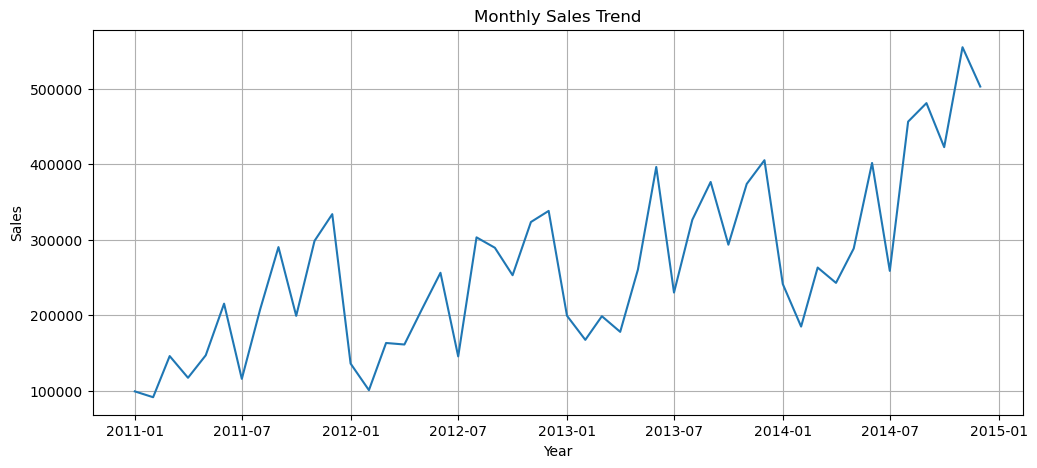

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index, monthly_revenue['sales'])
plt.title('Monthly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

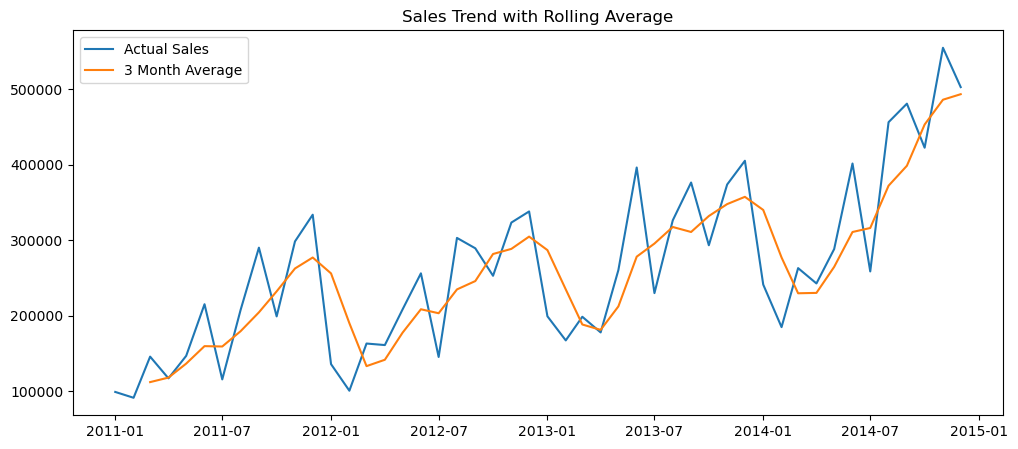

In [55]:
monthly_revenue['rolling_3m_avg'] = monthly_revenue['sales'].rolling(window=3).mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index, monthly_revenue['sales'], label='Actual Sales')
plt.plot(monthly_revenue.index, monthly_revenue['rolling_3m_avg'], label='3 Month Average')
plt.legend()
plt.title('Sales Trend with Rolling Average')
plt.show()

In [57]:
monthly_revenue = monthly_revenue.asfreq('MS')  # Monthly Start frequency
monthly_revenue.isnull().sum()

sales             0
rolling_3m_avg    2
dtype: int64

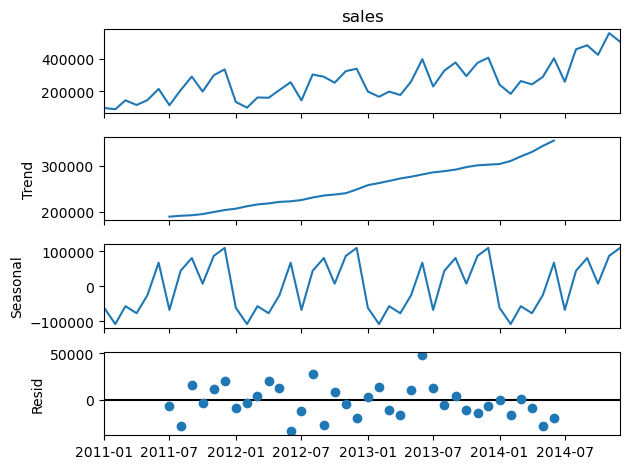

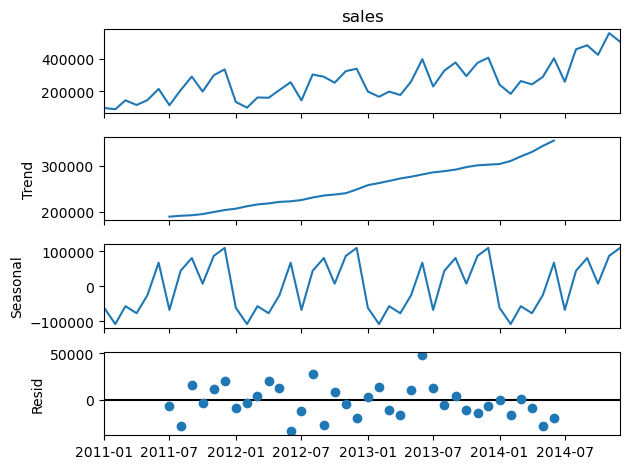

In [59]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_revenue['sales'], model='additive')

decomposition.plot()

In [61]:
monthly_revenue.describe()
monthly_revenue['sales'].idxmax(), monthly_revenue['sales'].max()

(Timestamp('2014-11-01 00:00:00'), 555312)

<Axes: title={'center': 'Sales with 6 Month Moving Average'}, xlabel='year_month'>

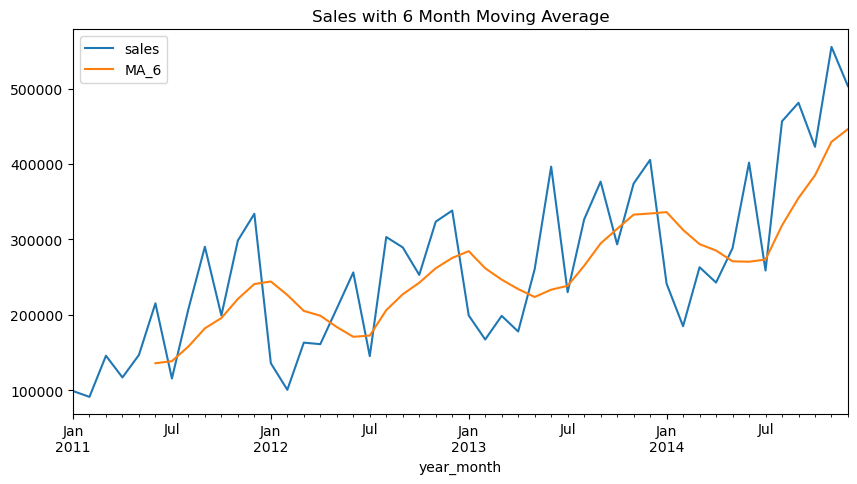

In [63]:
monthly_revenue['MA_6'] = monthly_revenue['sales'].rolling(window=6).mean()

monthly_revenue[['sales','MA_6']].plot(figsize=(10,5), title='Sales with 6 Month Moving Average')

In [65]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(monthly_revenue['sales'], order=(1,1,1))
model_fit = model.fit()

model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -598.715
Date:                Sun, 01 Feb 2026   AIC                           1203.431
Time:                        19:00:36   BIC                           1208.981
Sample:                    01-01-2011   HQIC                          1205.519
                         - 12-01-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0148      0.341      0.043      0.965      -0.653       0.683
ma.L1         -0.4748      0.352     -1.349      0.177      -1.165       0.215
sigma2      7.753e+09   8.31e-12   9.33e+20      0.000    7.75e+09    7.75e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 1.60
Prob(Q):                              0.72   Prob(JB):                         0.45
Heteroskedasticity (H):               1.42   Skew:                            -0.35
Prob(H) (two-sided):                  0.49   Kurtosis:                         2.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.95e+37. Standard errors may be unstable.
"""

In [67]:
forecast = model_fit.forecast(steps=6)

forecast

2015-01-01    499311.618279
2015-02-01    499254.741431
2015-03-01    499253.899512
2015-04-01    499253.887049
2015-05-01    499253.886865
2015-06-01    499253.886862
Freq: MS, Name: predicted_mean, dtype: float64

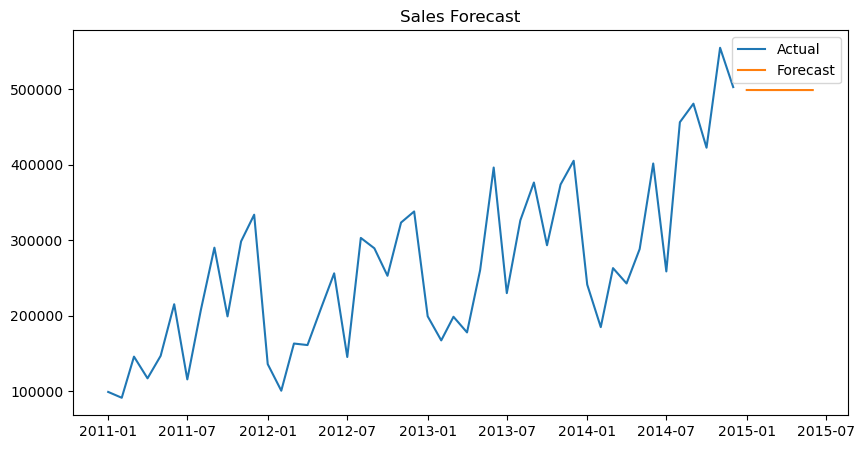

In [69]:
plt.figure(figsize=(10,5))

plt.plot(monthly_revenue.index, monthly_revenue['sales'], label='Actual')
plt.plot(forecast.index, forecast.values, label='Forecast')

plt.title('Sales Forecast')
plt.legend()
plt.show()

In [71]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_revenue['sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.6184018167932417
p-value: 0.9880605281990905


In [73]:
df['year_month'] = df['order_date'].dt.to_period('M')

In [77]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(monthly_revenue['sales'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

model_fit = model.fit()

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [79]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    monthly_revenue['sales'],
    order=(1,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()

model_fit.summary()

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              sales   No. Observations:                   43
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -190.993
Date:                            Sun, 01 Feb 2026   AIC                            389.987
Time:                                    19:13:36   BIC                            393.077
Sample:                                06-01-2011   HQIC                           390.145
                                     - 12-01-2014                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1977      1.187     -0.167      0.868      -2.523       2.128
ma.L1         -0.2972      0.996     -0.298      0.766      -2.250       1.656
ma.S.L12      -0.3430      0.511     -0.672      0.502      -1.344       0.658
sigma2      1.865e+09   1.82e-10   1.02e+19      0.000    1.86e+09    1.86e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.16
Prob(Q):                              0.96   Prob(JB):                         0.56
Heteroskedasticity (H):               9.58   Skew:                             0.66
Prob(H) (two-sided):                  0.03   Kurtosis:                         3.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.24e+35. Standard errors may be unstable.
"""

In [81]:
forecast = model_fit.forecast(steps=6)

forecast

2015-01-01    378713.596170
2015-02-01    325768.579090
2015-03-01    390261.642925
2015-04-01    371840.171199
2015-05-01    424152.847519
2015-06-01    538800.598869
Freq: MS, Name: predicted_mean, dtype: float64

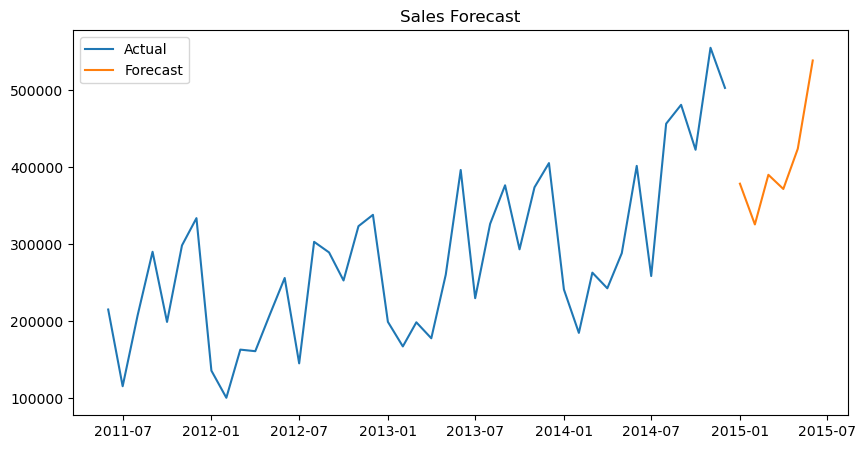

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_revenue.index, monthly_revenue['sales'], label='Actual')
plt.plot(forecast.index, forecast.values, label='Forecast')

plt.title('Sales Forecast')
plt.legend()
plt.show()

In [85]:
forecast_result = model_fit.get_forecast(steps=6)

forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

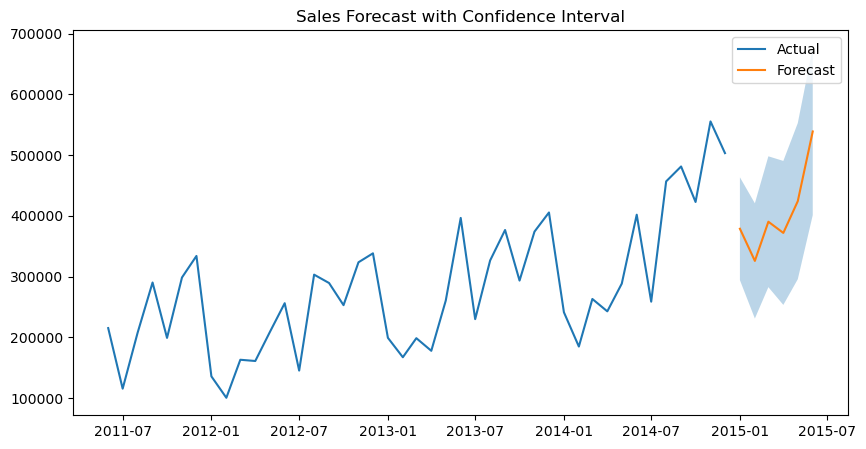

In [87]:
plt.figure(figsize=(10,5))

plt.plot(monthly_revenue.index, monthly_revenue['sales'], label='Actual')

plt.plot(forecast_mean.index, forecast_mean.values, label='Forecast')

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)

plt.title('Sales Forecast with Confidence Interval')
plt.legend()
plt.show()

In [89]:
seasonal_order=(0,1,0,12)
forecast_result = model_fit.get_forecast(steps=12)

In [91]:
forecast_result = model_fit.get_forecast(steps=12)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

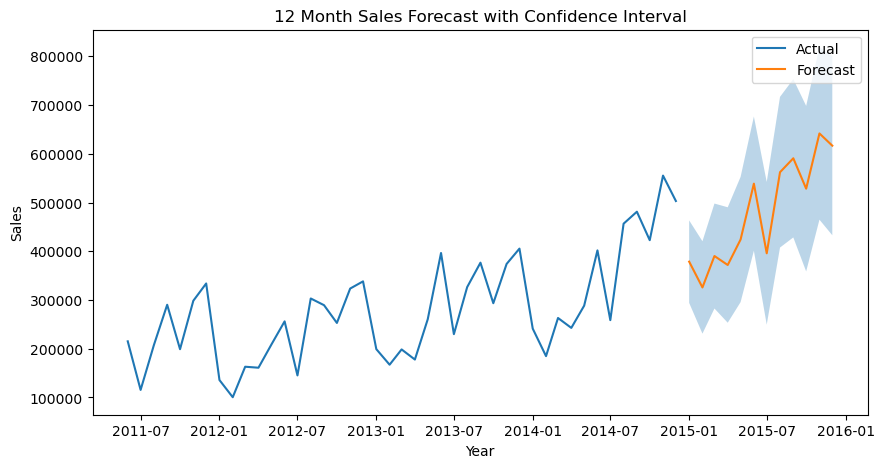

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Actual sales
plt.plot(monthly_revenue.index, monthly_revenue['sales'], label='Actual')

# Forecast
plt.plot(forecast.index, forecast.values, label='Forecast')

# Confidence Interval
plt.fill_between(
    forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.3
)

plt.title('12 Month Sales Forecast with Confidence Interval')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [95]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [97]:
hw_model = ExponentialSmoothing(
    monthly_revenue['sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

hw_fit = hw_model.fit()

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [99]:
hw_forecast = hw_fit.forecast(steps=12)

hw_forecast

2015-01-01    357899.522394
2015-02-01    322725.694617
2015-03-01    368701.472800
2015-04-01    356831.505709
2015-05-01    421582.412281
2015-06-01    513706.810532
2015-07-01    374562.849982
2015-08-01    501134.303669
2015-09-01    518774.208431
2015-10-01    458446.846978
2015-11-01    533947.094158
2015-12-01    568873.424329
Freq: MS, dtype: float64

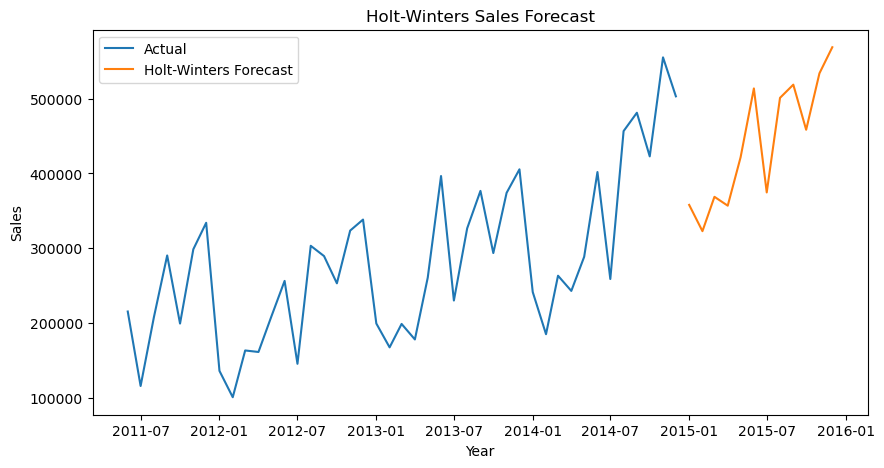

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_revenue.index, monthly_revenue['sales'], label='Actual')
plt.plot(hw_forecast.index, hw_forecast.values, label='Holt-Winters Forecast')

plt.title('Holt-Winters Sales Forecast')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()

plt.show()

In [103]:
model = SARIMAX(
    monthly_revenue['sales'],
    order=(1,1,1),
    seasonal_order=(0,1,1,12)
)

In [105]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    monthly_revenue['sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

hw_fit = hw_model.fit(optimized=True)

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [107]:
train = monthly_revenue.iloc[:-12]
test = monthly_revenue.iloc[-12:]

In [109]:
sarima_model = SARIMAX(
    train['sales'],
    order=(1,1,1),
    seasonal_order=(0,1,1,12)
)

sarima_fit = sarima_model.fit()

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [111]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train['sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

hw_fit = hw_model.fit(optimized=True)

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [113]:
sarima_forecast = sarima_fit.forecast(steps=12)
hw_forecast = hw_fit.forecast(steps=12)

In [115]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_mae = mean_absolute_error(test['sales'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test['sales'], sarima_forecast))

hw_mae = mean_absolute_error(test['sales'], hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test['sales'], hw_forecast))

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)

print("Holt-Winters MAE:", hw_mae)
print("Holt-Winters RMSE:", hw_rmse)

SARIMA MAE: 39941.59227588225
SARIMA RMSE: 46557.727058033735
Holt-Winters MAE: 44640.36928536667
Holt-Winters RMSE: 60753.44771234585


In [117]:
final_model = SARIMAX(
    monthly_revenue['sales'],
    order=(1,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit()

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [119]:
final_forecast = final_fit.forecast(steps=12)

final_forecast

2015-01-01    378713.596170
2015-02-01    325768.579090
2015-03-01    390261.642925
2015-04-01    371840.171199
2015-05-01    424152.847519
2015-06-01    538800.598869
2015-07-01    395816.875212
2015-08-01    562286.772477
2015-09-01    590837.163847
2015-10-01    528485.059517
2015-11-01    641801.028929
2015-12-01    616709.182762
Freq: MS, Name: predicted_mean, dtype: float64

In [121]:
forecast_df = final_forecast.reset_index()
forecast_df.columns = ['date', 'forecast_sales']

forecast_df.to_csv("final_sales_forecast.csv", index=False)

In [1]:
import os
os.listdir()

['.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.vscode',
 'anaconda3',
 'AppData',
 'Application Data',
 'Basic jupyter.ipynb',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'final_sales_forecast.csv',
 'Links',
 'Local Settings',
 'Microsoft',
 'ML 2024',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'PrintHood',
 'Recent',
 'RetailBusinessAnalytics.ipynb',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Untitled.ipynb',
 'untitled.txt',
 'Untitled1.ipynb',
 'Videos']

In [3]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_i2', 'json', 'getpass', 'hashlib', 'import_pandas_safely', '__pandas', 'is_data_frame', 'dataframe_columns', 'dtypes_str', 'dataframe_hash', 'get_dataframes', '_2', '_i3'])

In [7]:
get_dataframes()

'{"dataframes": [], "user": "hp"}'

In [1]:
import pandas as pd

df = pd.read_csv("Desktop/sales_clean.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [5]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [7]:
df[['order_date', 'ship_date']].dtypes

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

In [9]:
monthly_revenue = df.groupby(pd.Grouper(key='order_date', freq='MS'))['sales'].sum()
monthly_revenue.head()

order_date
2011-01-01    4081206645114553142769126673382118541931591951...
2011-02-01    2862912061633524013101404182782320212112101,05...
2011-03-01    5511,3141,4713646342467051,2442154585883771953...
2011-04-01    4972965681581398486123804868122452044302518671...
2011-05-01    2,7541,0574801,3892463095213372661562362888147...
Freq: MS, Name: sales, dtype: object

In [11]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [13]:
monthly_revenue = df.groupby(pd.Grouper(key='order_date', freq='MS'))['sales'].sum()

In [15]:
monthly_revenue.head()

order_date
2011-01-01    64363.0
2011-02-01    60848.0
2011-03-01    78983.0
2011-04-01    80698.0
2011-05-01    91536.0
Freq: MS, Name: sales, dtype: float64

In [17]:
hist_df = monthly_revenue.reset_index()
hist_df.columns = ['date', 'sales']

hist_df['year'] = hist_df['date'].dt.year
hist_df['month'] = hist_df['date'].dt.month

hist_df.to_csv("historical_monthly_sales.csv", index=False)

In [19]:
hist_df.head()

,date,sales,year,month
0,2011-01-01,64363.0,2011,1
1,2011-02-01,60848.0,2011,2
2,2011-03-01,78983.0,2011,3
3,2011-04-01,80698.0,2011,4
4,2011-05-01,91536.0,2011,5
